<a href="https://colab.research.google.com/github/pedrojrcruz30-code/PROJETO_FINAL_CONTINUADA/blob/main/projeto_final_continuada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJETO FINAL**
## **Inteligência de Carteira NeoCard**

**Entrega:** Notebook (`.ipynb`) + dataset utilizado

---

### **1. O Cliente: NeoCard**

A **NeoCard** é a divisão de cartões de crédito de um banco de varejo de porte médio. A carteira ativa reúne clientes dos segmentos *Classic, Gold, Platinum e Black*, distribuídos pelas cinco regiões do país.

Nos últimos meses, a *Diretoria de Inteligência de Cliente* identificou que decisões importantes — de precificação, de alocação de limite e de priorização de campanhas — vêm sendo tomadas com base em impressões e relatos pontuais das agências, sem um diagnóstico estruturado da base.

> **Cenário:** Você e sua equipe foram contratados como uma consultoria externa para entregar o primeiro diagnóstico analítico completo da carteira de clientes e do comportamento de consumo via cartão.

---

### **O Briefing**

* **De:** Diretoria de Inteligência de Cliente — NeoCard  
* **Para:** Equipe de Consultoria de Dados  
* **Assunto:** Diagnóstico da carteira de cartões — primeira entrega  

> *"Precisamos entender quem são nossos clientes, como o consumo se comporta entre segmentos e regiões, e quais sinais a base esconde sob a sujeira que sempre existe em dado real de produção.*
>
> *Quero um material que eu possa levar para a mesa de diretoria: direto, visual, e com conclusões que eu consiga usar para decidir. Vocês têm liberdade para explorar, mas eu preciso de respostas."*

---


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import openpyxl

df_NeoCard = pd.read_excel("neocard_dataset.xlsx")

display(df_NeoCard)

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
1,3492,31,Norte,Classic,NaN,15597.73,100,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
3,3926,38,Sul,Gold,NaN,16385.55,201,App,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
...,...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação,Cartão Múltiplo NeoCard
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App,Cartão Múltiplo NeoCard
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App,Cartão Múltiplo NeoCard
3998,3508,43,Centro-Oeste,Platinum,NaN,18291.19,71,App,Cartão Múltiplo NeoCard


## 1 - Solicitamos informações/resumo inicias do meu dataset

In [2]:
df_NeoCard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB


# Volume e Tamanho dos Dados

Total de Registros: O DataFrame possui 4.000 entradas (indexadas de 0 a 3.999).

Total de Colunas: Há 9 colunas no total.

# Presença de Valores Ausentes (Dados Faltantes)

Alerta de Dados Faltantes: A coluna score_credito possui apenas 3.820 valores não-nulos. Isso significa que existem 180 linhas com valores ausentes (nulos) nessa variável. Será necessário tratar esses dados (por exemplo, preenchendo com a média/mediana ou excluindo essas linhas)

## 2 - Descobrindo quantas linhas brancas temos em cada coluna

In [3]:
df_NeoCard.isnull().sum()

,0
id_cliente,0
idade,0
regiao,0
segmento_cartao,0
score_credito,180
limite_credito,0
tempo_relacionamento_meses,0
canal_aquisicao,0
produto_core,0


## 3 - Obtendo um resumo estatístico rápido das suas colunas numéricas (por padrão) ou categóricas.

In [4]:
df_NeoCard.describe()

,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,4000.000000,4000.00000,3820.000000,4000.000000,4000.000000
mean,2000.500000,41.22350,640.286911,16896.565375,121.799500
std,1154.844867,14.28678,79.827894,15518.950412,69.750513
min,1.000000,-5.00000,425.000000,8124.240000,1.000000
25%,1000.750000,33.00000,579.000000,14357.762500,60.000000
50%,2000.500000,41.00000,632.000000,15913.115000,122.000000
75%,3000.250000,49.00000,695.000000,17777.115000,185.000000
max,4000.000000,200.00000,897.000000,395222.440000,239.000000


## ⚠️ Inconsistências Críticas (Precisam de Tratamento)

idade (Problemas graves de qualidade de dados):

- Existe idade negativa, isso indica um erro de preenchimento ou ruído no sistema.

- Uma idade de 200 anos é biologicamente impossível, o que confirma a presença de outliers (valores discrepantes) que precisam ser removidos ou corrigidos.

### obs: Optei por achar/contar a quantidade de idades negativas e idades acima de 100 anos.

In [7]:
# Contar quantas idades são negativas
qtd_negativas = (df_NeoCard['idade'] < 0).sum()

# Contar quantas idades são acima de 100 anos
qtd_acima = (df_NeoCard['idade'] > 100).sum()

print(f"Quantidade de idades negativas: {qtd_negativas}")
print(f"Quantidade de idades acima de 100 anos: {qtd_acima}")
print(f"Total de registros com erro na idade: {qtd_negativas + qtd_acima}")

Quantidade de idades negativas: 7
Quantidade de idades acima de 100 anos: 13
Total de registros com erro na idade: 20


# 4 - Visualizar idades negativas

obs: decidi observar os dados com idades negativas já que eram poucos, para ver se consigo tirar alguma conclusâo ou achar um padrão e assim realizar determinado tratamento.

ex: canal_aquisição

In [8]:

display(df_NeoCard[df_NeoCard['idade'] < 0])


,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
848,3729,-5,Sudeste,Gold,639.0,17940.27,76,App,Cartão Múltiplo NeoCard
951,3130,-5,Sudeste,Black,771.0,19757.40,102,App,Cartão Múltiplo NeoCard
1392,3829,-5,Nordeste,Black,764.0,20458.66,99,Agência,Cartão Múltiplo NeoCard
1471,3028,-5,Sudeste,Platinum,667.0,16957.20,187,Agência,Cartão Múltiplo NeoCard
3186,3952,-5,Sudeste,Black,831.0,22711.71,159,App,Cartão Múltiplo NeoCard
3204,39,-5,Sudeste,Classic,623.0,18825.27,156,Parceria Varejo,Cartão Múltiplo NeoCard
3214,1828,-5,Sudeste,Gold,609.0,15573.60,189,Agência,Cartão Múltiplo NeoCard


# 5 - Visualizar idades acima de 100 anos

In [9]:

display(df_NeoCard[df_NeoCard['idade'] > 100])

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
1071,3101,150,Sudeste,Black,859.0,20316.51,213,Parceria Varejo,Cartão Múltiplo NeoCard
1390,2006,150,Sudeste,Platinum,707.0,18462.78,113,App,Cartão Múltiplo NeoCard
1554,2616,150,Sul,Gold,681.0,16113.30,158,Agência,Cartão Múltiplo NeoCard
2249,994,200,Sudeste,Classic,716.0,18105.39,122,App,Cartão Múltiplo NeoCard
2321,2388,150,Sul,Classic,582.0,14387.74,62,Agência,Cartão Múltiplo NeoCard
2652,1880,150,Sudeste,Gold,652.0,17412.90,8,Agência,Cartão Múltiplo NeoCard
2849,1465,200,Sul,Gold,662.0,15522.70,37,App,Cartão Múltiplo NeoCard
2918,2076,150,Sudeste,Gold,676.0,15227.81,145,App,Cartão Múltiplo NeoCard
3207,91,200,Sul,Classic,557.0,13644.54,85,App,Cartão Múltiplo NeoCard
3423,1665,150,Sudeste,Platinum,726.0,15594.80,60,Parceria Varejo,Cartão Múltiplo NeoCard


## 6 - Imputação pela Mediana

Se por algum motivo de negócio não puder perder nenhuma linha (por exemplo, se esses clientes tiverem um histórico financeiro crucial nas outras colunas), o ideal é substituir os valores discrepantes pela mediana da idade.

Por que a mediana e não a média? Olhando o seu describe(), a idade máxima é 200, o que puxa a média para cima. A mediana (o valor de 50%, que é 41 anos) é mais segura contra outliers.

In [11]:
# Cria uma cópia para não afetar o original
df_NeoCard_tratado = df_NeoCard.copy()

# descobrindo a mediana
mediana_idade = df_NeoCard_tratado['idade'].median()

print('A mediana de idade é:', mediana_idade)


A mediana de idade é: 41.0


## 7 - Inserindo e Visualizando as alterações atraves do describe

In [14]:
# Aplica a alteração na cópia
df_NeoCard_tratado.loc[(df_NeoCard_tratado['idade'] <= 0) | (df_NeoCard_tratado['idade'] > 100), 'idade'] = mediana_idade

# Agora sim esse comando vai funcionar perfeitamente:
df_NeoCard_tratado.describe().round(2)


,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,4000.00,4000.00,3820.00,4000.00,4000.00
mean,2000.50,40.93,640.29,16896.57,121.80
std,1154.84,11.82,79.83,15518.95,69.75
min,1.00,18.00,425.00,8124.24,1.00
25%,1000.75,33.00,579.00,14357.76,60.00
50%,2000.50,41.00,632.00,15913.12,122.00
75%,3000.25,49.00,695.00,17777.12,185.00
max,4000.00,85.00,897.00,395222.44,239.00


obs: como podemos ver os valores de min e max da coluna Idade já não estão -5.00 e 200, respectivamente.


# 8 - Agora trataremos a coluna que contem dados em branco.

In [15]:
df_NeoCard_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB


## Analisando o resumo do DataFrame, já com alguns tratamentos, ainda consta um item a ser tratado se possivel: os valores ausentes (dados em branco), coluna (score_credito), que tem 3.820 valores preenchidos de um total de 4.000 linhas (ou seja, 180 valores nulos, cerca de 4,5% dos dados).

## Aqui optamos por tirar a mediana Geral (score_credito) para preenher os dados faltantes (180 valores nulos). obs: é mais Simples e rápido e não sofre distorção caso existam clientes com scores muito baixos ou muito altos (outliers) no dataset.

In [16]:
mediana_score = df_NeoCard_tratado['score_credito'].median()

print('Mediana do score_credito Geral:', mediana_score)

print('='* 70)

df_NeoCard_tratado['score_credito'] = df_NeoCard_tratado['score_credito'].fillna(mediana_score)

df_NeoCard_tratado.info()

Mediana do score_credito Geral: 632.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               4000 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB



## Não optei pela Remoção das Linhas (A mais radical)

A remoção das linhas não foi adotada para evitar o desperdício de dados. Excluir essas 180 contas significaria perder todo o histórico de limite de crédito e tempo de relacionamento desses clientes, informações valiosas que preferi preservar por meio da imputação.


# Visualizando o DataFrame já com alguns tratamentos.

In [17]:
df_NeoCard_tratado

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
3,3926,38,Sul,Gold,632.0,16385.55,201,App,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
...,...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação,Cartão Múltiplo NeoCard
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App,Cartão Múltiplo NeoCard
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App,Cartão Múltiplo NeoCard
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App,Cartão Múltiplo NeoCard


# Conseguimos uma informação valiosíssima sobre os dados: todas as 4.000 linhas da sua base possuem exatamente o mesmo produto, que é o 'Cartão Múltiplo NeoCard'. Não há nenhuma variação nessa coluna.

In [18]:
df_NeoCard_tratado['produto_core'].unique()


array(['Cartão Múltiplo NeoCard'], dtype=object)

In [19]:
df_NeoCard_tratado['produto_core'].value_counts()

,count
produto_core,
Cartão Múltiplo NeoCard,4000


# 9 - Optamos pela sua exclusão (coluna: "produto_core")

In [20]:
df_NeoCard_tratado.drop(columns=['produto_core'], inplace=False)



,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência
3,3926,38,Sul,Gold,632.0,16385.55,201,App
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo
...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App


In [21]:
df_NeoCard_tratado

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
3,3926,38,Sul,Gold,632.0,16385.55,201,App,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
...,...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação,Cartão Múltiplo NeoCard
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App,Cartão Múltiplo NeoCard
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App,Cartão Múltiplo NeoCard
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App,Cartão Múltiplo NeoCard


## obs: Fiz uma copia do df_NeoCard_tratado para não perder os dados tratados anteriomente e agora passa a se chamar df_NeoCard_definitivo (coluna produto_core excluida).

In [23]:
df_NeoCard_definitivo = df_NeoCard_tratado.copy()

df_NeoCard_definitivo.drop(columns=['produto_core'], inplace=True)

df_NeoCard_definitivo

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência
3,3926,38,Sul,Gold,632.0,16385.55,201,App
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo
...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App


## 10 - Fiz uma consulta para ver se tinha algum dados(linhas) duplicado no Dataframe.

In [24]:
# Retorna o número total de linhas duplicadas
df_NeoCard_definitivo.duplicated().sum()

np.int64(0)

# 11 - Dataframe ponto para analise.

In [194]:
df_NeoCard_definitivo

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação
1,3492,31,Norte,Classic,632.0,15597.73,100,Indicação
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência
3,3926,38,Sul,Gold,632.0,16385.55,201,App
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo
...,...,...,...,...,...,...,...,...
3995,1131,21,Sudeste,Black,806.0,20292.36,228,Indicação
3996,1295,58,Nordeste,Classic,588.0,14976.78,235,App
3997,861,38,Sudeste,Gold,627.0,15159.40,32,App
3998,3508,43,Centro-Oeste,Platinum,632.0,18291.19,71,App


In [26]:
df_NeoCard_definitivo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               4000 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 250.1+ KB


# 12 - Quantidade de cartões por segmento_cartão

In [27]:
# Agrupa por segmento, conta e já renomeia a Series
contagem_segmento = df_NeoCard_definitivo.groupby('segmento_cartao')['id_cliente'].count().rename('quantidade')

# Exibe o resultado
display(contagem_segmento)


,quantidade
segmento_cartao,
Black,290
Classic,1816
Gold,1170
Platinum,724


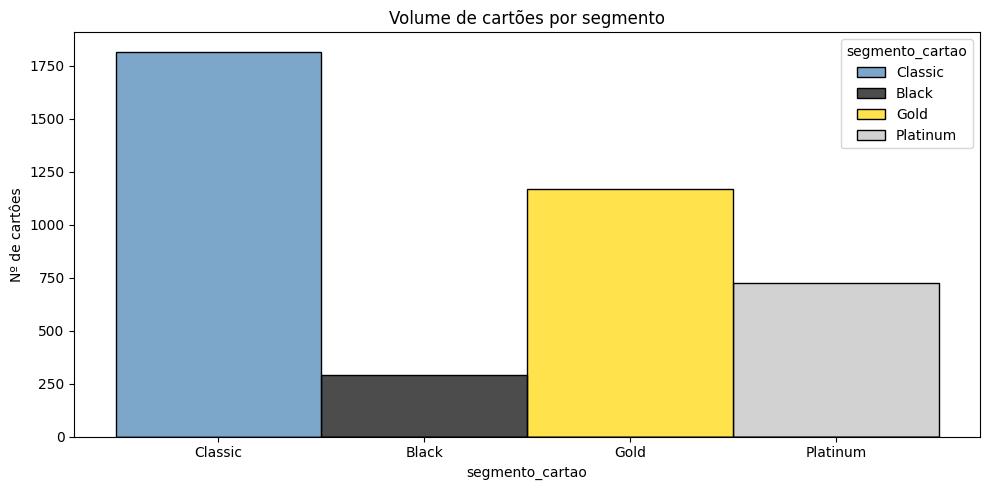

In [31]:
fig, ax = plt.subplots(figsize=(10,5)) # cria subáreas para poder trabalhar com gráficos independentes

cores_customizadas = {
    "Classic": "#4682B4",     # Um azul bonito (SteelBlue) para manter o padrão
    "Gold": "#FFD700",        # Dourado clássico
    "Black": "black",         # Preto
    "Platinum": "silver"      # Cinza/Prata (ou 'gray' se preferir mais escuro)
}

sns.histplot(
    data=df_NeoCard_definitivo, # os dados/dataframe
    x="segmento_cartao", # coluna que vai ser usada no eixo X
    #y="quantidade", # coluna que vai ser usada no eixo X
    hue="segmento_cartao", # semelhante ao group by, agrupando os dados por categoria
    palette=cores_customizadas, # define a paleta de cores personalizada
    bins=40, # quantidade de agrupamentos
    #kde=True, # linha com o a densidade de probabilidade
    alpha=0.7, # transparencia para sobreposição legível
    ax=ax # subarea usada
)

ax.set_title("Volume de cartões por segmento") # define o título do gráfico
ax.set_xlabel("segmento_cartao") # define a legenda do eixo x
ax.set_ylabel("Nº de cartôes") # define a legenda do eixo y

plt.tight_layout() # ajuste de visual
plt.show() # plota os gráficos

In [37]:
df_NeoCard_definitivo.describe().round(2)

,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,4000.00,4000.00,4000.00,4000.00,4000.00
mean,2000.50,40.93,639.91,16896.57,121.80
std,1154.84,11.82,78.03,15518.95,69.75
min,1.00,18.00,425.00,8124.24,1.00
25%,1000.75,33.00,582.00,14357.76,60.00
50%,2000.50,41.00,632.00,15913.12,122.00
75%,3000.25,49.00,691.00,17777.12,185.00
max,4000.00,85.00,897.00,395222.44,239.00


# 13 - Fazendo um describe agrupando por segmento_cartao e seu limite de creditos

In [38]:
df_NeoCard_definitivo.groupby('segmento_cartao')['limite_credito'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
segmento_cartao,,,,,,,,
Black,290.0,19612.63,1861.23,14546.88,18416.98,19648.46,20756.64,24925.36
Classic,1816.0,15245.10,14587.41,8124.24,13315.16,14617.50,15806.39,347348.96
Gold,1170.0,17144.62,14251.13,10145.86,15063.07,16313.48,17696.70,395222.44
Platinum,724.0,19550.13,21241.25,12080.20,16802.04,18120.60,19257.51,333357.61


## obs: No segmento Classic, por exemplo, a mediana (50%) é 14.617, mas o valor máximo chega a 347.348, o que joga o desvio padrão (std) lá para cima (14.587). O mesmo acontece com Gold e Platinum.

# 14 - Relação entre Score de Crédito e Limite de Crédito por Segmento
obs: aqui confirmamos os outliers (ex: limite de cartão basico com limite muito alto).

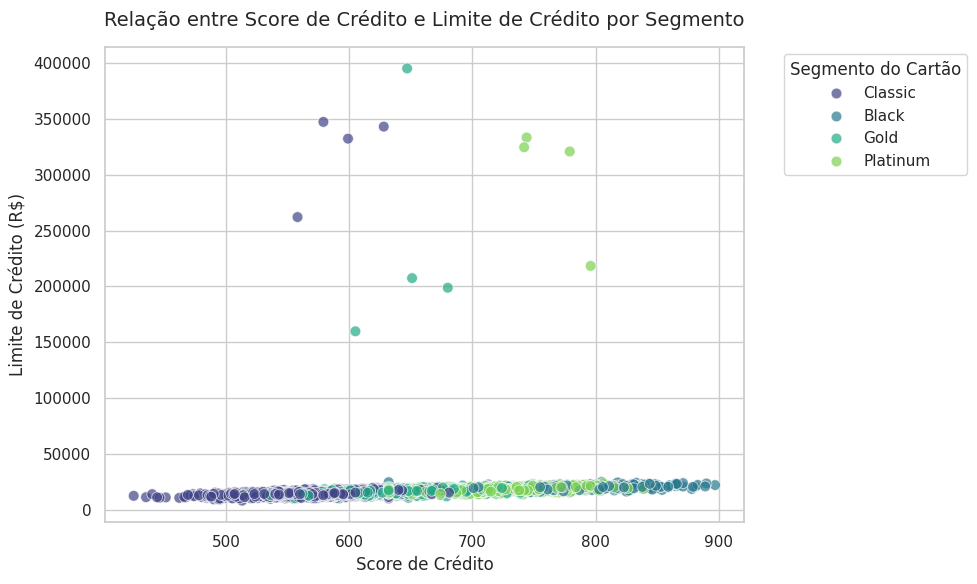

In [39]:
# Configurando o estilo e tamanho do gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criando o scatterplot
sns.scatterplot(
    data=df_NeoCard_definitivo,
    x="score_credito",
    y="limite_credito",
    hue="segmento_cartao",  # Cores baseadas no tipo de cartão (Classic, Gold, Black, etc.)
    palette="viridis",  # Paleta de cores moderna e legível
    alpha=0.7,  # Transparência para evitar pontos totalmente sobrepostos
    s=60,  # Tamanho dos pontos
)

# Customizando títulos e eixos
plt.title(
    "Relação entre Score de Crédito e Limite de Crédito por Segmento",
    fontsize=14,
    pad=15,
)
plt.xlabel("Score de Crédito", fontsize=12)
plt.ylabel("Limite de Crédito (R$)", fontsize=12)

# Ajustando a legenda para não cobrir os dados
plt.legend(title="Segmento do Cartão", bbox_to_anchor=(1.05, 1), loc="upper left")

# Exibindo o gráfico limpando resíduos de texto
plt.tight_layout()
plt.show()

## Padrão de Crescimento: Se você olhar bem para essa "linha" densa na base, ela tem uma leve inclinação para cima à medida que o score avança para a direita. Isso indica que, para o cliente comum, um score maior realmente traz um limite ligeiramente maior, mas dentro de uma faixa controlada e bem pé no chão.

In [41]:
q1 = df_NeoCard_definitivo['limite_credito'].quantile(0.25)
q3 = df_NeoCard_definitivo['limite_credito'].quantile(0.75)

print(q1)
print(q3)

iqr = q3 - q1

print(iqr)

lim_min = q1 - 1.5 * iqr
print(lim_min)

lim_max = q3 + 1.5 * iqr
print(lim_max)

14357.7625
17777.115
3419.352500000001
9228.73375
22906.143750000003


In [42]:
# Filtra os limites maiores que 30.000 e conta por segmento
df_NeoCard_definitivo[df_NeoCard_definitivo['limite_credito'] > 30000]['segmento_cartao'].value_counts()

,count
segmento_cartao,
Classic,4
Gold,4
Platinum,4


## obs: Decidi identificar quem são esses clientes para tomar uma decisão, ver se tem um padrao que possa localizar um erro/falha.

ex: um cliente de alta renda que está em um segmento_cartao errado.

In [49]:
# Mostra todas as colunas dessas 12 linhas específicas para você analisar
df_NeoCard_definitivo[df_NeoCard_definitivo['limite_credito'] > 30000]

,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
33,2465,35,Sudeste,Classic,628.0,343132.76,199,Indicação
60,3250,62,Sudeste,Gold,680.0,198820.93,215,App
225,2759,18,Sudeste,Gold,647.0,395222.44,173,App
352,1614,47,Nordeste,Classic,558.0,262085.73,22,Agência
446,140,24,Nordeste,Classic,579.0,347348.96,68,App
1395,3057,33,Centro-Oeste,Gold,651.0,207427.37,83,Agência
2106,3581,55,Sudeste,Platinum,744.0,333357.61,165,App
2133,3551,49,Centro-Oeste,Platinum,796.0,218333.59,229,App
2134,3725,46,Centro-Oeste,Platinum,742.0,324648.31,188,Parceria Varejo
2314,1419,38,Sul,Platinum,779.0,320829.36,229,Agência


## obs: Por nao encontrar um padrao e por ser poucos dados, optei por exclui-los já definindo novo nome para nossa DF (df_NeoCard_final).

In [50]:
# Cria o novo DataFrame filtrando apenas os limites menores que 30.000

df_NeoCard_final = df_NeoCard_definitivo[df_NeoCard_definitivo['limite_credito'] < 30000].copy()

df_NeoCard_final.describe().round(2)

,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,3988.00,3988.00,3988.00,3988.00,3988.00
mean,1998.63,40.93,639.83,16083.99,121.71
std,1154.71,11.82,78.02,2477.47,69.72
min,1.00,18.00,425.00,8124.24,1.00
25%,998.75,33.00,582.00,14355.66,60.00
50%,1997.50,41.00,632.00,15902.48,122.00
75%,2997.25,49.00,691.00,17746.72,185.00
max,4000.00,85.00,897.00,24925.36,239.00


# 15 - Relação entre Score de Crédito e Limite de Crédito por Segmento

## obs: já com a exclusao do outliers .

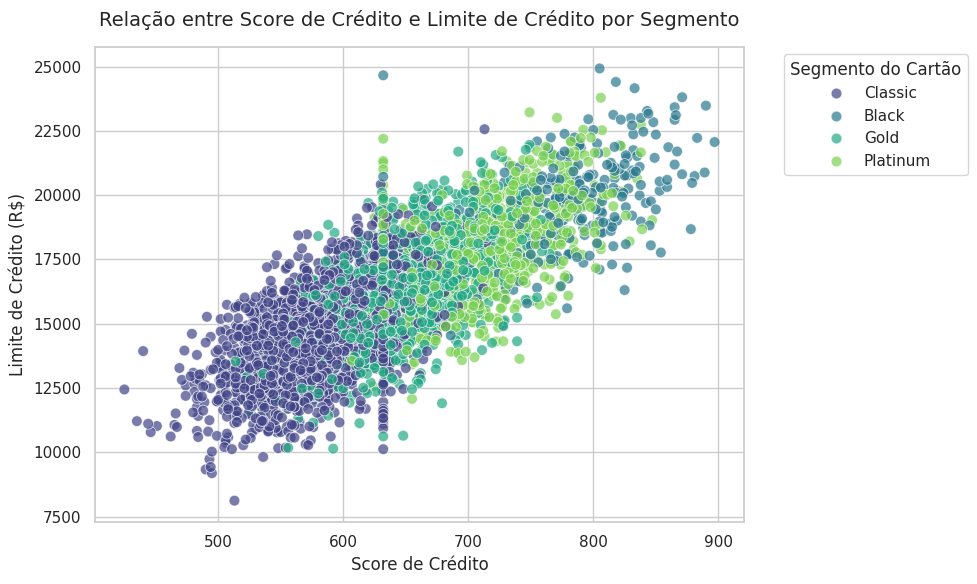

In [52]:
# Configurando o estilo e tamanho do gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criando o scatterplot
sns.scatterplot(
    data=df_NeoCard_final,
    x="score_credito",
    y="limite_credito",
    hue="segmento_cartao",  # Cores baseadas no tipo de cartão (Classic, Gold, Black, etc.)
    palette="viridis",  # Paleta de cores moderna e legível
    alpha=0.7,  # Transparência para evitar pontos totalmente sobrepostos
    s=60,  # Tamanho dos pontos
)

# Customizando títulos e eixos
plt.title(
    "Relação entre Score de Crédito e Limite de Crédito por Segmento",
    fontsize=14,
    pad=15,
)
plt.xlabel("Score de Crédito", fontsize=12)
plt.ylabel("Limite de Crédito (R$)", fontsize=12)

# Ajustando a legenda para não cobrir os dados
plt.legend(title="Segmento do Cartão", bbox_to_anchor=(1.05, 1), loc="upper left")

# Exibindo o gráfico limpando resíduos de texto
plt.tight_layout()
plt.show()

# Correlação Positiva Forte

Existe uma clara tendência de crescimento da esquerda para a direita. Isso significa que quanto maior o Score de Crédito do cliente, maior tende a ser o Limite de Crédito (R$) concedido. É um comportamento esperado no mercado financeiro, onde um score mais alto indica menor risco e, consequentemente, maior abertura para limites altos.

# 16 - Para ver a média de limite e score de crédito por segmento:

In [53]:
df_NeoCard_final.groupby('segmento_cartao')[['limite_credito', 'score_credito']].mean().round(2)

,limite_credito,score_credito
segmento_cartao,,
Black,19612.63,778.51
Classic,14569.64,581.19
Gold,16379.05,650.22
Platinum,17996.00,714.72


## 17 - Para contar quantos clientes têm cada tipo de cartão e em termos percentuais.

In [54]:
# Cria um DataFrame com a contagem e o percentual
analise_segmento = df_NeoCard_final.groupby('segmento_cartao')['id_cliente'].agg(
    Quantidade='count',
    Percentual=lambda x: (x.count() / len(df_NeoCard_final)) * 100
)

# Opcional: formata a coluna de percentual para exibir o símbolo % e duas casas decimais
analise_segmento['Percentual'] = analise_segmento['Percentual'].map('{:.2f}%'.format)

analise_segmento

,Quantidade,Percentual
segmento_cartao,,
Black,290,7.27%
Classic,1812,45.44%
Gold,1166,29.24%
Platinum,720,18.05%


# 18 - Estatística Descritiva Geral (Idade, Score e Limite)

In [55]:
resumo_geral = df_NeoCard_final[['idade', 'score_credito', 'limite_credito']].describe().round(2)
display(resumo_geral)

,idade,score_credito,limite_credito
count,3988.00,3988.00,3988.00
mean,40.93,639.83,16083.99
std,11.82,78.02,2477.47
min,18.00,425.00,8124.24
25%,33.00,582.00,14355.66
50%,41.00,632.00,15902.48
75%,49.00,691.00,17746.72
max,85.00,897.00,24925.36


O que observar no resultado:

1.   Média (mean) vs Mediana (50%): Se a média de limite_credito for muito maior que a mediana, significa que você tem alguns clientes com limites absurdamente altos puxando a média para cima.

2.   Mínimos e Máximos (min/max): Para entender a amplitude do seu público (ex: se atendem desde jovens de 18 anos até idosos, ou scores muito baixos).



# 19 - O perfil muda por segmento de cartão?

### Agrupei por segmento e calculei a média das variáveis numéricas relevantes

In [58]:
perfil_por_segmento = df_NeoCard_final.groupby('segmento_cartao')[['idade', 'score_credito', 'limite_credito']].mean().round(2)
display(perfil_por_segmento)

,idade,score_credito,limite_credito
segmento_cartao,,,
Black,41.07,778.51,19612.63
Classic,41.04,581.19,14569.64
Gold,40.63,650.22,16379.05
Platinum,41.06,714.72,17996.00


💡 Dica de ouro: Como a média pode ser afetada por valores extremos (outliers), vale muito a pena rodar também com a mediana para ver se o padrão se mantém estável:

In [59]:
perfil_por_segmento_mediana = df_NeoCard_final.groupby('segmento_cartao')[['idade', 'score_credito', 'limite_credito']].median().round(2)
display(perfil_por_segmento_mediana)

,idade,score_credito,limite_credito
segmento_cartao,,,
Black,41.0,779.5,19648.46
Classic,41.0,580.0,14614.26
Gold,40.0,648.0,16311.84
Platinum,41.0,715.0,18095.56


Ao olhar a tabela gerada pelo código acima, repare em padrões comuns de mercado. Geralmente, espera-se que:

Score de Crédito: Cartões como Black e Platinum apresentem uma média de score significativamente maior que o Classic.

Limite de Crédito: O limite deve crescer progressivamente conforme a categoria do cartão sobe (Classic < Gold < Platinum < Black).

Idade: é bem distribuída entre os segmentos.

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lendo a aba específica e ajustando os decimais
df_transacoes = pd.read_excel("neocard_dataset.xlsx", sheet_name="transacoes")

display(df_transacoes)

,id_transacao,id_cliente,data_transacao,categoria,valor_transacao,canal_transacao
0,1,3565,2025-12-01,Supermercado,366.83,Presencial
1,2,2116,2025-04-23,Eletrônicos,1190.44,Presencial
2,3,877,2025-04-18,Restaurante,53.68,Presencial
3,4,2457,2025-08-19,Supermercado,180.42,App/Online
4,5,933,2025-04-02,Vestuário,146.71,Presencial
...,...,...,...,...,...,...
216056,216057,1454,2025-07-22,Educação,1009.13,Presencial
216057,216058,2472,2025-07-06,Supermercado,172.40,App/Online
216058,216059,3345,2025-08-22,Streaming,40.70,App/Online
216059,216060,1659,2025-01-05,Supermercado,198.62,App/Online


# 1 - Solicitamos informações/resumo inicias do meu dataset

In [177]:
df_transacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_transacao     216061 non-null  int64         
 1   id_cliente       216061 non-null  int64         
 2   data_transacao   216061 non-null  datetime64[ns]
 3   categoria        216061 non-null  object        
 4   valor_transacao  213900 non-null  float64       
 5   canal_transacao  216061 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB


## obs: A coluna valor_transacao tem 213.900 valores preenchidos de um total de 216.061, o que significa que ela possui 2.161 valores nulos.

In [131]:
df_transacoes.isnull().sum()

,0
id_transacao,0
id_cliente,0
data_transacao,0
categoria,0
valor_transacao,2161
canal_transacao,0


# 2 -Descobrindo a porcentagem de valores nulos

In [178]:
# Retorna a porcentagem direta de nulos nessa coluna
porcentagem_nulos = df_transacoes['valor_transacao'].isnull().mean() * 100
print(f"{porcentagem_nulos:.2f}%")

1.00%


# 3 - Visualizando alguns dados nulos para ver se encontra um padrão.

In [179]:
df_transacoes[df_transacoes['valor_transacao'].isnull()]

,id_transacao,id_cliente,data_transacao,categoria,valor_transacao,canal_transacao
196,197,2722,2025-10-04,Combustível,NaN,App/Online
211,212,8,2025-09-21,Outros,NaN,Presencial
268,269,3036,2025-12-16,Supermercado,NaN,Presencial
350,351,3782,2025-01-07,Outros,NaN,Presencial
496,497,1759,2025-07-18,Combustível,NaN,Presencial
...,...,...,...,...,...,...
215551,215552,753,2025-04-12,Farmácia,NaN,Presencial
215588,215589,162,2025-08-31,Supermercado,NaN,Presencial
215633,215634,2570,2025-10-08,Eletrônicos,NaN,App/Online
215737,215738,2218,2025-09-23,Restaurante,NaN,Presencial


# obs: Se você rodar o código acima e notar que, por exemplo, todos os 2.161 nulos pertencem à categoria "Presencial" ou "App/Online", você acabou de encontrar um padrão claro, porém não foi o caso.

# 4 - Ver se os nulos estão concentrados em um único lugar filtrando o DataFrame e contando as ocorrências

In [180]:
# Filtra apenas onde o valor é nulo e conta quantas vezes cada categoria aparece
df_transacoes[df_transacoes['valor_transacao'].isnull()]['categoria'].value_counts()

,count
categoria,
Supermercado,445
Restaurante,333
Vestuário,226
Combustível,210
Farmácia,201
Eletrônicos,181
Outros,172
Streaming,134
Viagem,123


# 5 - Padronização da coluna Categoria

In [181]:
df_transacoes_padronizada = df_transacoes.copy()

df_transacoes_padronizada['categoria'] = df_transacoes_padronizada['categoria'].str.capitalize()

# nova consulta para verificar a padronização
df_transacoes_padronizada[df_transacoes_padronizada['valor_transacao'].isnull()]['categoria'].value_counts()


,count
categoria,
Supermercado,457
Restaurante,335
Vestuário,229
Combustível,213
Farmácia,202
Eletrônicos,184
Outros,176
Streaming,134
Viagem,126


# 6 - Consultando a quantidade de valores nulos por canal de transação

In [182]:
df_transacoes_padronizada[df_transacoes_padronizada['valor_transacao'].isnull()]['canal_transacao'].value_counts()

,count
canal_transacao,
Presencial,1200
App/Online,961


In [80]:
# configuração recomendada para toda análise
sns.set_theme(style="whitegrid", palette="muted")

## 5 — Distribuição de valores nulos pelo canal de transação

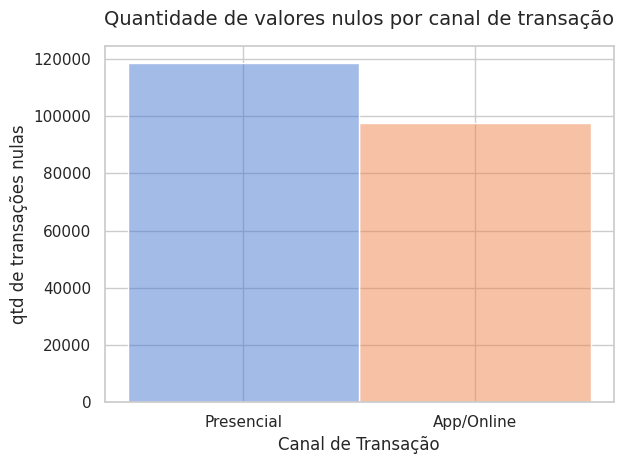

In [184]:
sns.histplot(
    data=df_transacoes_padronizada,
    x="canal_transacao",
    bins =150,
    hue="canal_transacao",
    legend=False)

# Customizando títulos e eixos
plt.title(
    "Quantidade de valores nulos por canal de transação",
    fontsize=14,
    pad=15,

)
plt.xlabel("Canal de Transação", fontsize=12)
plt.ylabel("qtd de transações nulas", fontsize=12)



# Exibindo o gráfico limpando resíduos de texto
plt.tight_layout()
plt.show()

# 7 - Fazendo o merge (join) entre as 2 DF (df_transacoes_padronizada + df_NeoCard_final)

In [203]:
# Fazendo o merge (Join) trazendo as informações do cliente para a tabela de transações
df_completo = pd.merge(
    df_transacoes_padronizada,
    df_NeoCard_final,
    on="id_cliente",
    how="inner"
)

# Exibindo o novo DataFrame unificado
display(df_completo)

,id_transacao,id_cliente,data_transacao,categoria,valor_transacao,canal_transacao,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao
0,1,3565,2025-12-01,Supermercado,366.83,Presencial,33,Sudeste,Black,817.0,21083.94,84,Parceria Varejo
1,2,2116,2025-04-23,Eletrônicos,1190.44,Presencial,65,Nordeste,Platinum,782.0,20901.95,146,App
2,3,877,2025-04-18,Restaurante,53.68,Presencial,58,Sudeste,Classic,599.0,16282.71,184,Agência
3,4,2457,2025-08-19,Supermercado,180.42,App/Online,40,Sudeste,Gold,635.0,16889.41,97,Indicação
4,5,933,2025-04-02,Vestuário,146.71,Presencial,34,Nordeste,Classic,658.0,19067.11,97,Parceria Varejo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215397,216057,1454,2025-07-22,Educação,1009.13,Presencial,32,Sul,Black,804.0,21632.68,72,App
215398,216058,2472,2025-07-06,Supermercado,172.40,App/Online,32,Sudeste,Platinum,733.0,16890.50,188,Agência
215399,216059,3345,2025-08-22,Streaming,40.70,App/Online,30,Sudeste,Gold,656.0,17925.10,137,Parceria Varejo
215400,216060,1659,2025-01-05,Supermercado,198.62,App/Online,24,Sul,Classic,578.0,14816.53,223,Indicação


In [204]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215402 entries, 0 to 215401
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   id_transacao                215402 non-null  int64         
 1   id_cliente                  215402 non-null  int64         
 2   data_transacao              215402 non-null  datetime64[ns]
 3   categoria                   215402 non-null  object        
 4   valor_transacao             213248 non-null  float64       
 5   canal_transacao             215402 non-null  object        
 6   idade                       215402 non-null  int64         
 7   regiao                      215402 non-null  object        
 8   segmento_cartao             215402 non-null  object        
 9   score_credito               215402 non-null  float64       
 10  limite_credito              215402 non-null  float64       
 11  tempo_relacionamento_meses  215402 non-

In [205]:
df_completo.isnull().sum()

,0
id_transacao,0
id_cliente,0
data_transacao,0
categoria,0
valor_transacao,2154
canal_transacao,0
idade,0
regiao,0
segmento_cartao,0
score_credito,0


In [206]:
# 1. Agrupando por segmento e região e calculando as métricas agregadas
analise_segmento_regiao = df_completo.groupby(['segmento_cartao', 'regiao']).agg(
    numero_transacoes=('id_transacao', 'count'),
    gasto_total=('valor_transacao', 'sum'),
    clientes_unicos=('id_cliente', 'nunique')
).reset_index().round(2)

# 2. Calculando o gasto médio por cliente
analise_segmento_regiao['gasto_medio_por_cliente'] = (
    analise_segmento_regiao['gasto_total'] / analise_segmento_regiao['clientes_unicos']
)
# Arredonda a nova coluna para 2 casas decimais
analise_segmento_regiao['gasto_medio_por_cliente'] = analise_segmento_regiao['gasto_medio_por_cliente'].round(2)

# 3. Removendo a coluna auxiliar
analise_final = analise_segmento_regiao.drop(columns=['clientes_unicos'])

# Exibindo o resultado
display(analise_final)

,segmento_cartao,regiao,numero_transacoes,gasto_total,gasto_medio_por_cliente
0,Black,Centro-Oeste,3241,950270.94,32767.96
1,Black,Nordeste,6430,1820696.13,30344.94
2,Black,Norte,1854,512613.01,30153.71
3,Black,Sudeste,13674,3774683.22,30440.99
4,Black,Sul,6422,1934192.58,32236.54
5,Classic,Centro-Oeste,6074,1653045.77,9555.18
6,Classic,Nordeste,13418,3776253.38,9488.07
7,Classic,Norte,3736,1071611.21,9922.33
8,Classic,Sudeste,26009,7331165.45,9684.50
9,Classic,Sul,13123,3727452.79,9913.44


# 1. O Domínio Absoluto da Região Sudeste

## Em todos os segmentos de cartão, a região Sudeste é a líder disparada, concentrando o maior volume de transações e o maior faturamento total (gasto_total).

## Exemplo de peso: No segmento Gold (linha 13), o Sudeste sozinho registrou 28.845 transações e um faturamento superior a R$ 8,4 milhões — quase o dobro da segunda colocada (Nordeste).

#2. Padrão Inverso: Volume vs. Valor do Ticket

## Existe uma dinâmica clara de funil de consumo entre os segmentos:

## Classic & Gold (Alto Volume, Baixo Ticket): São os cartões de massa. O volume de transações é gigante (especialmente no Sudeste e Nordeste), mas o gasto médio por cliente fica nas faixas mais baixas (aprox. R$ 9.500 para Classic e R$ 15.000 para Gold).

## Black & Platinum (Baixo Volume, Alto Ticket): O número de transações cai drasticamente, mas o gasto médio por cliente dispara. O segmento Black entrega o maior valor por cliente, flutuando entre R$ 30.000 e R$ 32.700 dependendo da região.

#3. O Fenômeno do Centro-Oeste no Segmento Black

##Embora a região Centro-Oeste costume ter volumes totais de transações menores que o Sudeste e o Nordeste, ela surpreende em um indicador crucial:

## O Centro-Oeste possui o maior gasto médio por cliente no segmento Black (R$ 32.767,96), superando inclusive o Sudeste (R$ 30.440,99).

## Insight: Isso sugere que, embora haja menos clientes "Black" no Centro-Oeste, o poder aquisitivo ou a concentração de gastos desse público específico é extremamente alta (forte relação com o agronegócio, possivelmente).

#4. O Norte como Mercado de Menor Penetração, mas com Ticket Saudável

## A região Norte figura consistentemente na última posição em número de transações e gasto total em todos os cartões. No entanto, o comportamento de consumo de quem possui os cartões é muito similar ao das outras regiões. Por exemplo, o gasto médio do cliente Black no Norte é de R$ 30.153,71, muito próximo da média nacional do segmento.

# Resumo para Tomada de Decisão:

## Foco em Volume/Market Share: Campanhas para cartões Classic e Gold devem focar massivamente no Sudeste e Nordeste.

## Foco em Alta Renda/Rentabilidade: Campanhas de upgrade para o segmento Black têm um público altamente qualificado e de valor expressivo no Centro-Oeste e no Sul, além do tradicional Sudeste.


In [212]:
# configuração recomendada para toda análise
sns.set_theme(style="whitegrid", palette="muted")

# 8 - Para comparar volumes entre categorias:

## Quer descobrir qual canal_transacao (Presencial vs. App/Online) é mais utilizado, ou qual regiao domina a base?

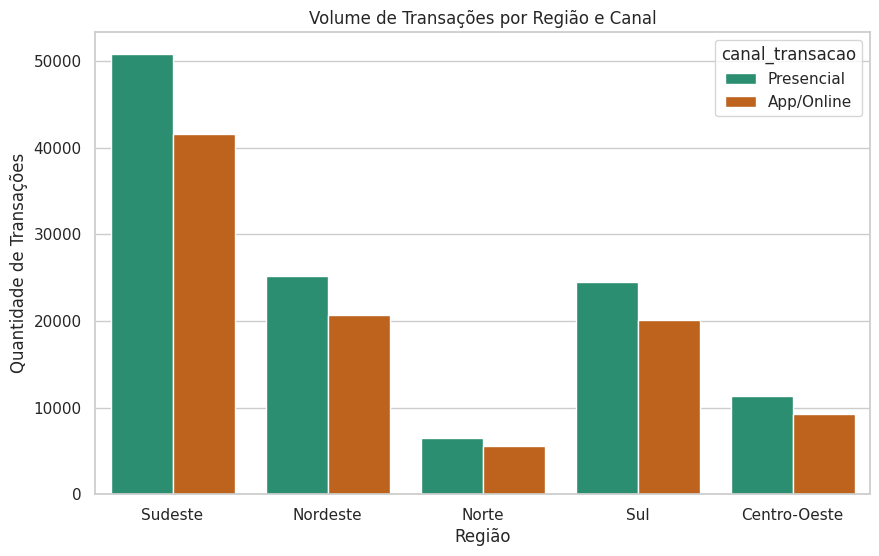

In [213]:
plt.figure(figsize=(10, 6))
# Conta quantas transações aconteceram por região, divididas pelo canal
sns.countplot(data=df_completo, x='regiao', hue='canal_transacao', palette='Dark2')

plt.title('Volume de Transações por Região e Canal')
plt.xlabel('Região')
plt.ylabel('Quantidade de Transações')
plt.show()

# 9 - A evolução do faturamento ao longo do tempo dividido por Segmento de Cartão (Black, Platinum, etc.) ou por Canal (Presencial vs Online).

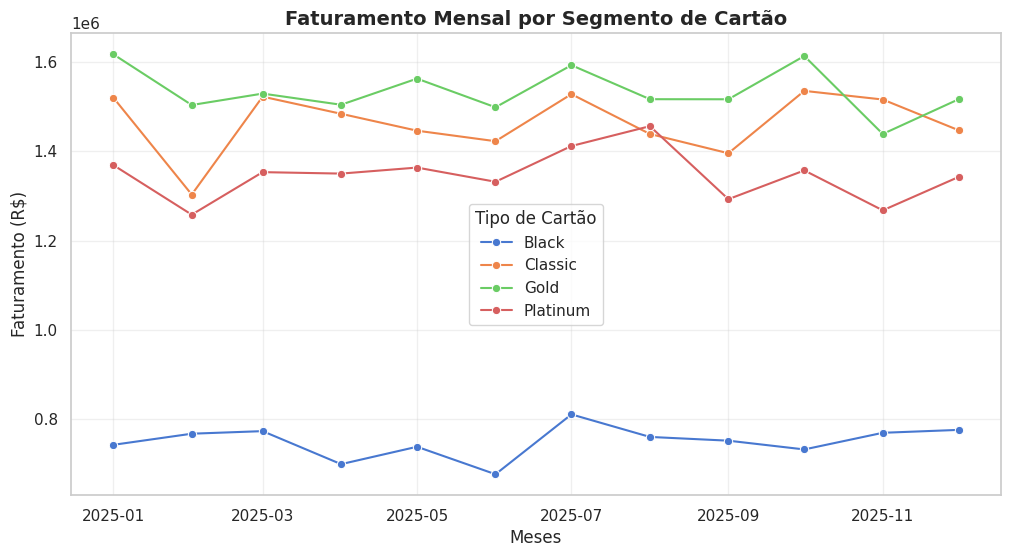

In [214]:
# Agrupando por Mês E por Segmento de Cartão
df_segmento_tempo = df_completo.groupby([df_completo['data_transacao'].dt.to_period('M'), 'segmento_cartao'])['valor_transacao'].sum().reset_index()
df_segmento_tempo['data_transacao'] = df_segmento_tempo['data_transacao'].dt.to_timestamp()

plt.figure(figsize=(12, 6))

# O argumento 'hue' cria uma linha para cada tipo de cartão
sns.lineplot(data=df_segmento_tempo, x='data_transacao', y='valor_transacao', hue='segmento_cartao', marker='o')

plt.title('Faturamento Mensal por Segmento de Cartão', fontsize=14, fontweight='bold')
plt.xlabel('Meses', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.legend(title='Tipo de Cartão')
plt.grid(True, alpha=0.3)

plt.show()

In [215]:
# Verifica a quantidade de transações e a média de gasto por segmento
df_completo.groupby('segmento_cartao').agg(
    quantidade_transacoes=('id_transacao', 'count'),
    gasto_medio=('valor_transacao', 'mean'),
    faturamento_total=('valor_transacao', 'sum')
)

,quantidade_transacoes,gasto_medio,faturamento_total
segmento_cartao,,,
Black,31621,287.436659,8992455.88
Classic,62360,284.429322,17559528.60
Gold,64145,289.848649,18411476.04
Platinum,57276,284.864543,16153528.77


# O resultado do seu agrupamento mostrar que o Classic fatura mais simplesmente porque tem muito mais clientes do que o Black, não há nada de errado com os dados — é apenas a realidade do negócio (a massa consome mais em volume total do que o nicho de alta renda).

#Recomendações:

# 1. Foco no Segmento "Gold" e "Classic" (Líderes de Faturamento)

## Esses dois segmentos disputam o topo do faturamento ao longo de quase todo o ano, com valores consistently altos (entre R$ 1,4M e R$ 1,6M).

## Ações de Engajamento: Como são a principal força motriz do faturamento, vale a pena criar campanhas de fidelidade e cashback voltadas para manter esses clientes ativos, especialmente nos meses onde há quedas simultâneas.

## Estratégia de Parcerias: Fortalecer parcerias com grandes varejistas ou marketplaces onde o público das categorias Classic e Gold costuma consumir para garantir a recorrência.

# 2. Oportunidade de Upsell para o Segmento "Platinum"

## O segmento Platinum roda constantemente abaixo do Classic e Gold (em torno de R$ 1,3M a R$ 1,4M). Em um cenário tradicional, cartões Platinum deveriam gerar um faturamento maior por cliente (ticket médio mais alto).

## Campanhas de Upsell: Identifique os clientes do segmento Gold que possuem um limite alto ou gastos consistentes e ofereça o upgrade para o Platinum, com benefícios que justifiquem a migração.

## Revisão de Benefícios: Se os clientes Platinum estão gastando menos que os Classic/Gold no total, pode ser que os benefícios atuais do cartão não estejam atraentes o suficiente para centralizar os gastos deles. Vale a pena revisar os diferenciais (pontuação, seguros, salas VIP).

# 3. Alavancagem do Segmento "Black" (Alta Renda)

## O faturamento do Black é o menor em volume total (abaixo de R$ 0,8M). Isso é normal por ser um público de nicho (exclusivo), mas há um comportamento interessante: ele teve um pico forte em julho (2025-07) e se manteve mais estável durante as quedas de fim de ano dos outros cartões.

## Campanhas de Sazonalidade (Julho): Investigue o que causou o pico em julho (férias de inverno, viagens internacionais, etc.) e replique essa estratégia ou crie benefícios específicos de viagem e turismo focados nesse período para os próximos anos.

## Estratégia de Aquisição de Clientes (MGM): Criar programas de indicação ("Member Get Member") focados no público Black, pois atrair poucos clientes de altíssimo poder aquisitivo nesse segmento pode mover o ponteiro do faturamento rapidamente.